In [2]:
%cd /iridisfs/home/lhl1g23/ssm/mamba
import warnings
warnings.filterwarnings('ignore')
from models.dataloaders.dataloaders import get_sc
from analyse.utils.plots import plot_eigen, plot_frequency_repsponse_one_step, plot_z_transform_one_step, plot_jacobian_dy_dt, plot_variance, plot_real_eigen
from analyse.utils.eval import accuracy
from train.train_classifier import MambaClassifierTrainer
from omegaconf import OmegaConf
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

train, val, test = get_sc()
train_iter, val_iter, test_iter = iter(train), iter(val), iter(test)
SUBSET_CLASSES = ["yes","no","up","down","left","right","on","off","stop","go"]

/iridisfs/home/lhl1g23/ssm/mamba


CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


In [3]:
X, y = next(test_iter)
X, y = X.to('cuda'),y.to('cuda')
X, y = X[:1], y[:1]

In [5]:
config = OmegaConf.load('models/configs/sc/complex_circle.yaml')

model = MambaClassifierTrainer.load_from_checkpoint(
    '/scratch/lhl1g23/mamba/checkpoints/sc/raw/complex/circle/best-v19.ckpt',
    data="sc",
    mamba_config=config.mamba,
    model_config=config.model
).to('cuda')

model.eval()
torch.set_grad_enabled(False)

params_iter = model.classifier.get_params(X[:1], requires_grad=False)
mamba_out, logits = model.classifier(X[:1])
classifier = model.classifier.classifier

In [6]:
X_embed = model.classifier.embed(X)
X_mamba, _ = model.classifier.mamba.layers[0].mixer.in_proj(X_embed).chunk(2, dim=-1)

params = next(params_iter)

A = params['A']
B = params['B']
C = params['C']
D = params['D']
dA = params['dA']
dB = params['dB']
dt = params['dt']
states = params['states']
y_ssm = params['y_ssm']
y_out = params['y_out']

In [ ]:
plot_eigen(torch.flatten(dA[0, 11000, :, :].cpu()), plt.gca(), s=5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = torch.flatten(dA[0, 11000, :, :]).cpu().numpy()
plot_real_eigen(x)

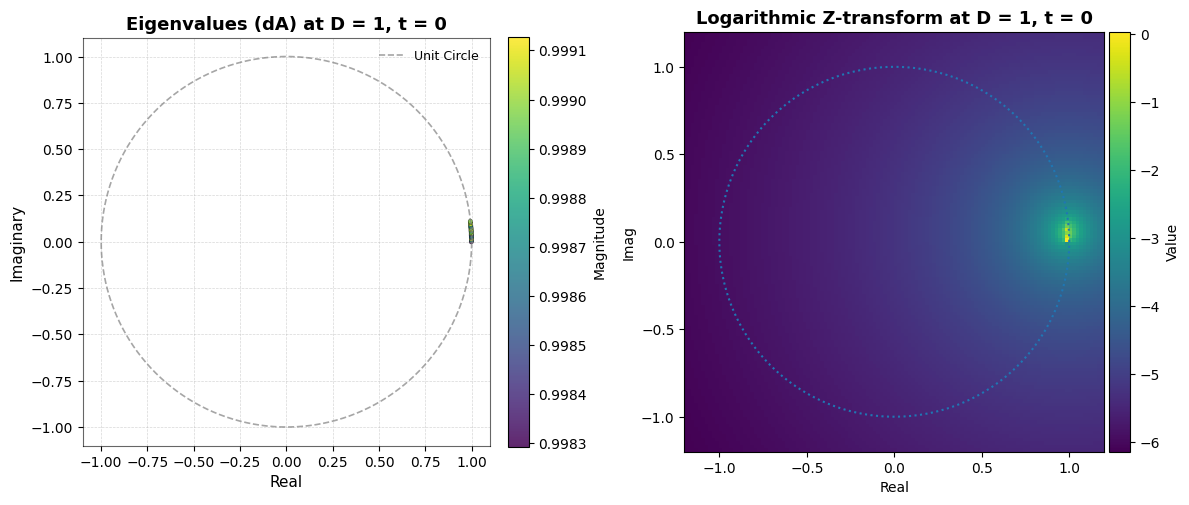

In [22]:
from analyse.utils.transforms import frequency_response_one_step
from scipy.signal import find_peaks

sample, d, t = 0, 1, 0

fig, ax = plt.subplots(1, 2, figsize=(12,6))
plot_eigen(dA[sample, t, d, :].to('cpu'), ax[0], s=10, title=f"Eigenvalues (dA) at D = {d}, t = {t}")
plot_z_transform_one_step(dA, dB, C, sample, d, t, ax=ax[1], log=True)
#plot_frequency_repsponse_one_step(dA, dB, C, sample, d, t, ax[2])

""" f = torch.abs(frequency_response_one_step(dA, dB, C, t))
angles = torch.atan2(dA[sample,t,d].imag, dA[sample,t,d].real) % (2 * torch.pi)
peaks = angles * 16000 / (2 * torch.pi)

freq_axis = torch.linspace(0, 16000, 360).cuda()

for peak in peaks:
    idx = (torch.abs(freq_axis - peak)).argmin().item()
    ax[2].plot(freq_axis[idx].cpu(), f[sample, d, idx].cpu(), 'x', color='red', markersize=8)
    
plt.tight_layout()
plt.show() """
plt.tight_layout()
plt.show()

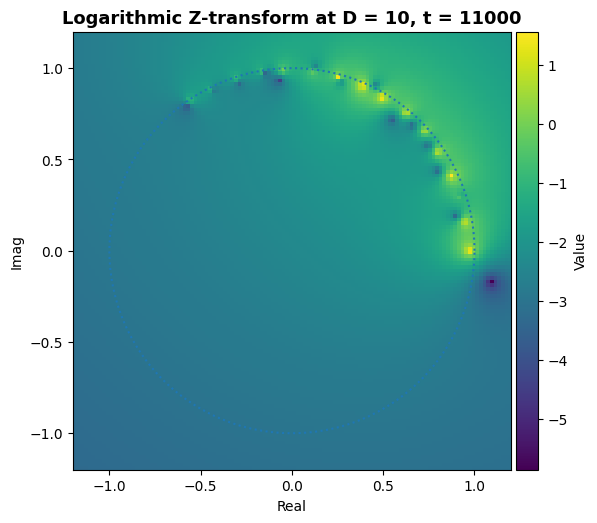

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plot_z_transform_one_step(dA, dB, C, sample, d, 11000, ax=ax, log=True)

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 6))
ax[0].plot(mamba_out.mean(1)[0].cpu()[:10])
ax[1].plot(classifier[2].weight[5].cpu()[:10])

In [ ]:
def plot_variance(M, ax, window=100, title="Eigenvalues variance over time"):
    b, l = M.shape[:2]
    reshaped = M.reshape(b, l, -1)

    variances = []
    for t in range(l):
        end = min(l, t + window)
        v = torch.var(reshaped[:, t:end], dim=1).mean()
        variances.append(v)

    variances = torch.stack(variances).detach().cpu().numpy()
    x = np.arange(len(variances))

    kernel = np.ones(5) / 5
    smooth = np.convolve(variances, kernel, mode="same")

    ax.plot(x, variances, alpha=0.3, linewidth=1)
    ax.plot(x, smooth, linewidth=2)

    ax.set_xlabel("Time step")
    ax.set_ylabel("Variance")
    ax.set_title(title)

    ax.grid(alpha=0.2)

In [ ]:
fig, ax = plt.subplots(2,1, figsize=(12,6))
plot_variance(dA, ax[0], title="Eigenvalue variance of dA over time")
ax[1].plot(X[0,:,0].cpu().numpy())
ax[1].set_xlabel("Time step")
ax[1].set_ylabel("Amplitude")
ax[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12,6))
ax.set_xlim(-2, 2)
plot_eigen(torch.flatten(A).cpu(), ax, circle=False, title='Continuous A matrix eigenvalues')

In [ ]:
from analyse.utils.animation import animate_eigen

animate_eigen(X, dA, d_dim=15, save_path='analyse/animations/animation.gif')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10), 
                          gridspec_kw={'width_ratios': [4, 1]})

plot_jacobian_dy_dt(params, X_mamba, 0, 0, axes[0], log=True)

l = X[0].shape[0]
axes[1].plot(X[0].to('cpu'), torch.arange(l))
axes[1].invert_yaxis() 
axes[1].sharey(axes[0])  
axes[1].set_xlabel("Amplitude")
axes[1].set_ylabel("")
axes[1].yaxis.set_visible(False) 

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 20))

l = X[0].shape[0]
ax[1].plot(X[0].to('cpu'))
ax[1].set_ylabel("Amplitude")

plot_jacobian_dy_dt(params, X_mamba, 0, 0, ax[0], log=True, cbar=False)

In [4]:
config = OmegaConf.load('models/configs/sc/complex_circle.yaml')

model = MambaClassifierTrainer(
    data="sc",
    mamba_config=config.mamba,
    model_config=config.model
).to('cuda')

model.eval()
torch.set_grad_enabled(False)

params_iter = model.classifier.get_params(X[:1], requires_grad=False)
params = next(params_iter)

A = params['A']
B = params['B']
C = params['C']
D = params['D']
dA = params['dA']
dB = params['dB']
dt = params['dt']
states = params['states']
y_ssm = params['y_ssm']
y_out = params['y_out']

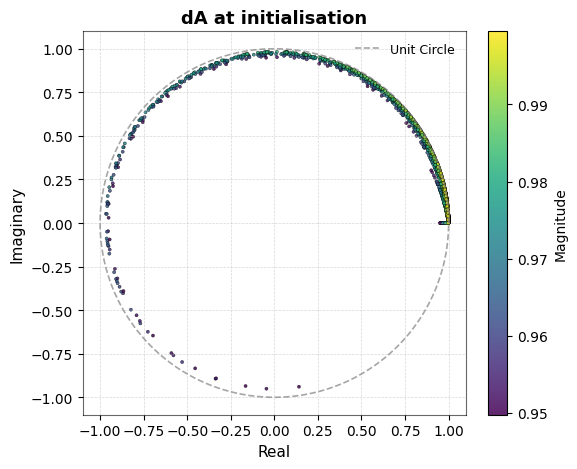

In [6]:
plot_eigen(torch.flatten(dA[0, 0, :, :].cpu()), plt.gca(), s=5, title="dA at initialisation")